In [2]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [9]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import VarianceThreshold
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from PMAPUtil import *

In [24]:
myTreatmentColumn = 'hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'death_at_disch', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aSkipTemp = True) 

In [33]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor),  ('variance', myVariance), ('imputer', myImputer), ('covariates', myCovariates)]

In [27]:
X_train = X_train.loc[:, X_train.isnull().mean() < 0.9]
X_test = X_test[X_train.columns]

In [28]:
DefaultGrid = [
    {
        'clf': [XGBClassifier(eval_metric='logloss')],
        'clf__n_estimators': [25, 100, 500], 
        'clf__max_depth': [10, 50, 100]
    },
    # {
    #     'clf': [XGBClassifier(eval_metric='logloss')],
    #     'clf__n_estimators': [50], 
    #     'clf__max_depth': [10]
    # }
    # {
    #     'clf': [DecisionTreeClassifier()],
    #     'clf__max_depth': [2, 5, 20, 50, None],
    #     'clf__class_weight': [None, 'balanced']
    # },
    # {
    #     'clf': [LogisticRegression(), SVC(probability=True)],
    #     'clf__C': [0.01, 0.1, 1, 10, 100]
    # }
    # {
    #     'clf': [KerasClassifier(model=build_model, epochs=30, batch_size=32, verbose=1)]
    # }
]
def gridSearchKFoldClassification(X_train, X_test, y_train, y_test, aScore = 'roc_auc', aGrid = DefaultGrid):
    kf = StratifiedKFold(n_splits=5, shuffle=True)
    myPipelineSteps = getDefaultPipelineSteps(X_train = X_train)
    myPipelineSteps.append(('clf', XGBClassifier()))
    myPipeline = Pipeline(myPipelineSteps)
    myGridSearchCv = GridSearchCV(myPipeline, aGrid, cv=kf, scoring=aScore, n_jobs=-1, verbose=3)
    myGridSearchCv.fit(X_train, y_train)
    myBestModel = myGridSearchCv.best_estimator_
    y_pred_proba = myBestModel.predict_proba(X_test)[:, 1]
    y_pred = myBestModel.predict(X_test)
    print(f'Best parameters: {myGridSearchCv.best_params_}')
    print(f'Best cross val {aScore} score: {myGridSearchCv.best_score_:.4f}')
    print(f'Area under the receiver operating curve on test set is {roc_auc_score(y_test, y_pred_proba):.4f}')
    print(f'Accuracy score on test set is {accuracy_score(y_test, y_pred):.4f}')
    return myGridSearchCv
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc', aGrid = DefaultGrid)
myBestModel = myGridSearchCv.best_estimator_

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...), clf__max_depth=10, clf__n_estimators=25;, score=0.769 total time=  22.6s
[CV 1/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
        

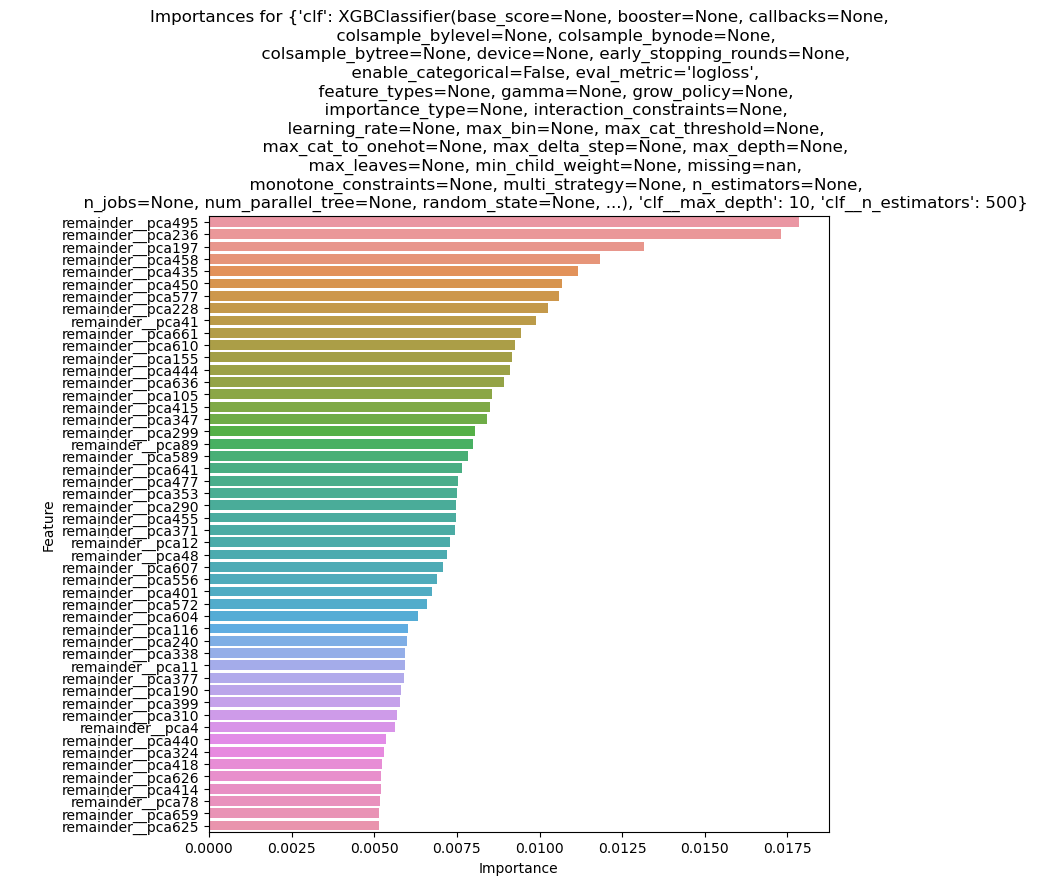

In [29]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.covariates.get_feature_names_out()), X_train, y_train)

In [30]:
myFeatureImportancesDf[myFeatureImportancesDf.Feature == 'keep__keep__bin__hypothermia']

,Feature,Importance
0,keep__keep__bin__hypothermia,0.002501


In [31]:
myX = pd.concat([X_train.reset_index().drop(columns='index'), X_test.reset_index().drop(columns='index')])
myY = pd.concat([y_train.reset_index().drop(columns='index'), y_test.reset_index().drop(columns='index')])

Optimization terminated successfully.
         Current function value: 0.548702
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.548651
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.13153410816926225
p-value: 0.7168466960000841
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 1292
Model:                          Logit   Df Residuals:                     1289
Method:                           MLE   Df Model:                            2
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                 0.01367
Time:                        19:37:25   Log-Likelihood:                -708.92
converged:                       True   LL-Null:                       -718.75
Covariance Type:            nonrobust   LLR p-value:                 5.424e-05
                     

0.7168466960000841

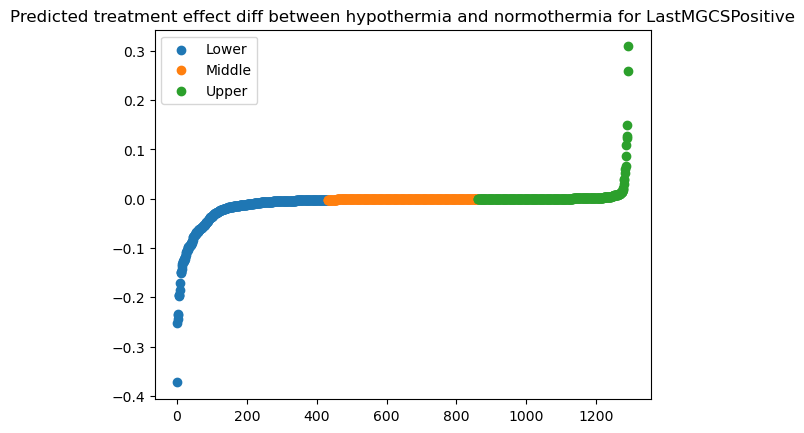

In [23]:
getTreatmentEffectDiff(aX = myX.reset_index().drop(columns='index'), aY = myY.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'LastMGCSPositive', aGroup = 'hypothermia', aUseNeuralNetwork = False, aByGroup = False)

Optimization terminated successfully.
         Current function value: 0.638373
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.638352
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.05754005451285593
p-value: 0.8104270993703321
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                 1416
Model:                          Logit   Df Residuals:                     1413
Method:                           MLE   Df Model:                            2
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                0.004561
Time:                        19:39:58   Log-Likelihood:                -903.94
converged:                       True   LL-Null:                       -908.08
Covariance Type:            nonrobust   LLR p-value:                   0.01590
                     

0.8104270993703321

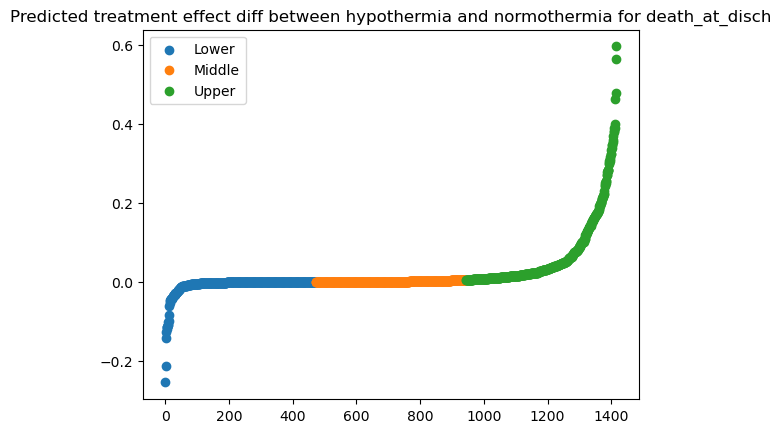

In [32]:
getTreatmentEffectDiff(aX = myX.reset_index().drop(columns='index'), aY = myY.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'death_at_disch', aGroup = 'hypothermia', aUseNeuralNetwork = False, aByGroup = False)